In [96]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, confusion_matrix
from sklearn.linear_model import LinearRegression

## Load The Dataset

In [73]:
df = pd.read_csv(r"weather.csv")
df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1693301400,29-08-2023 14:00,28.8,83.8,Sunny,...,8.3,13.3,647.5,130.2,1.2,0.4,7.9,11.1,1,1
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1693301400,29-08-2023 11:30,27.0,80.6,Partly cloudy,...,7.4,11.9,433.9,104.4,3.6,1.8,28.2,29.6,2,3
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1693301400,29-08-2023 10:30,28.0,82.4,Partly cloudy,...,3.4,5.4,647.5,16.6,63.1,12.6,6.4,7.9,1,1
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1693301400,29-08-2023 11:30,10.2,50.4,Sunny,...,7.4,11.9,190.3,68.0,0.2,0.2,0.5,0.8,1,1
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1693301400,29-08-2023 10:30,25.0,77.0,Partly cloudy,...,3.6,5.8,2136.2,147.3,52.8,26.9,139.6,203.3,4,10


## Summary Of The Data

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135023 entries, 0 to 135022
Data columns (total 35 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       135023 non-null  object 
 1   location_name                 135023 non-null  object 
 2   latitude                      135023 non-null  float64
 3   longitude                     135023 non-null  float64
 4   timezone                      135023 non-null  object 
 5   last_updated_epoch            135023 non-null  int64  
 6   last_updated                  135023 non-null  object 
 7   temperature_celsius           133998 non-null  float64
 8   temperature_fahrenheit        133993 non-null  float64
 9   condition_text                135003 non-null  object 
 10  wind_mph                      135010 non-null  float64
 11  wind_kph                      133996 non-null  float64
 12  wind_degree                   134991 non-nul

## Statistical Summary Of The Data

In [75]:
df.describe()

,latitude,longitude,last_updated_epoch,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,pressure_in,...,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index
count,135023.000000,135023.000000,1.350230e+05,133998.000000,133993.000000,135010.000000,133996.000000,134991.000000,134992.000000,135000.000000,...,134997.000000,133994.000000,135023.000000,135023.000000,135023.000000,135023.000000,135023.000000,135023.000000,135023.000000,135023.000000
mean,19.185123,22.024850,1.725922e+09,21.685971,71.035937,8.048341,12.975132,168.489603,1013.885067,29.939372,...,11.892441,19.161052,535.456868,57.441335,15.244491,10.324009,25.816433,51.378030,1.712168,2.662109
std,24.482024,65.785243,1.868481e+07,9.698528,17.457301,7.253151,11.696022,103.996215,10.457941,0.308739,...,8.719327,14.054557,1054.786243,34.011629,26.363121,36.634134,49.275046,149.683607,1.011875,2.609537
min,-41.300000,-175.200000,1.693301e+09,-41.900000,-43.400000,2.200000,3.600000,1.000000,947.000000,27.960000,...,0.000000,0.000000,-9999.000000,0.000000,0.000000,-9999.000000,0.168000,-1848.150000,1.000000,1.000000
25%,3.750000,-6.836100,1.708708e+09,16.100000,61.000000,3.800000,6.100000,80.000000,1010.000000,29.830000,...,6.700000,10.800000,236.800000,35.000000,1.200000,0.700000,5.100000,8.146500,1.000000,1.000000
50%,17.250000,23.316700,1.727085e+09,24.200000,75.600000,6.900000,11.200000,160.000000,1013.000000,29.920000,...,10.300000,16.600000,314.500000,55.800000,4.600000,2.220000,12.950000,19.500000,1.000000,2.000000
75%,40.400000,50.580000,1.742032e+09,28.200000,82.800000,11.000000,17.600000,255.000000,1018.000000,30.060000,...,15.800000,25.500000,487.300000,76.000000,16.835000,8.000000,28.305000,44.770000,2.000000,3.000000
max,64.150000,179.220000,1.756973e+09,49.200000,120.600000,1841.200000,2963.200000,360.000000,3006.000000,88.770000,...,1845.700000,2970.400000,41870.102000,555.000000,575.800000,557.000000,1614.100000,6037.290000,6.000000,10.000000


## Checking Null Values

In [76]:
df.isnull().sum()

country                            0
location_name                      0
latitude                           0
longitude                          0
timezone                           0
last_updated_epoch                 0
last_updated                       0
temperature_celsius             1025
temperature_fahrenheit          1030
condition_text                    20
wind_mph                          13
wind_kph                        1027
wind_degree                       32
wind_direction                     0
pressure_mb                       31
pressure_in                       23
precip_mm                         27
precip_in                         33
humidity                          25
cloud                             31
feels_like_celsius                28
feels_like_fahrenheit             32
visibility_km                     24
visibility_miles                  31
uv_index                          20
gust_mph                          26
gust_kph                        1029
a

In [77]:
df.columns

Index(['country', 'location_name', 'latitude', 'longitude', 'timezone',
       'last_updated_epoch', 'last_updated', 'temperature_celsius',
       'temperature_fahrenheit', 'condition_text', 'wind_mph', 'wind_kph',
       'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in',
       'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius',
       'feels_like_fahrenheit', 'visibility_km', 'visibility_miles',
       'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide',
       'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
       'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
       'air_quality_us-epa-index', 'air_quality_gb-defra-index'],
      dtype='object')

Selection of Numerical Columns and Categorial Columns

In [78]:
df_num = df.select_dtypes(include='number')  
print(df_num)
df_cat = df.columns[df.dtypes == 'object']
print(df_cat)



        latitude  longitude  last_updated_epoch  temperature_celsius  \
0        34.5200    69.1800          1693301400                 28.8   
1        41.3300    19.8200          1693301400                 27.0   
2        36.7600     3.0500          1693301400                 28.0   
3        42.5000     1.5200          1693301400                 10.2   
4        -8.8400    13.2300          1693301400                 25.0   
...          ...        ...                 ...                  ...   
135018   10.5000   -66.9167          1756971900                 26.3   
135019   21.0333   105.8500          1756972800                 34.2   
135020   15.3547    44.2067          1756972800                 23.8   
135021  -15.4167    28.2833          1756972800                 25.3   
135022  -17.8178    31.0447          1756972800                 26.2   

        temperature_fahrenheit  wind_mph  wind_kph  wind_degree  pressure_mb  \
0                         83.8       7.2      11.5     

In [79]:
df.isnull().sum()

country                            0
location_name                      0
latitude                           0
longitude                          0
timezone                           0
last_updated_epoch                 0
last_updated                       0
temperature_celsius             1025
temperature_fahrenheit          1030
condition_text                    20
wind_mph                          13
wind_kph                        1027
wind_degree                       32
wind_direction                     0
pressure_mb                       31
pressure_in                       23
precip_mm                         27
precip_in                         33
humidity                          25
cloud                             31
feels_like_celsius                28
feels_like_fahrenheit             32
visibility_km                     24
visibility_miles                  31
uv_index                          20
gust_mph                          26
gust_kph                        1029
a

In [80]:
for i in df_num:
    df[i] = df[i].fillna(df[i].median())
for i in df_cat:
    df[i] = df[i].fillna(df[i].mode()[0]) 

In [ ]:
for col in df_num:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot - {col}')
    plt.show()

## Outlier Detection & Handling

In [ ]:
for i in df_num:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[i] = df[i].clip(lower = lower, upper=upper)  

for col in df_num:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot - {col}')
    plt.show()




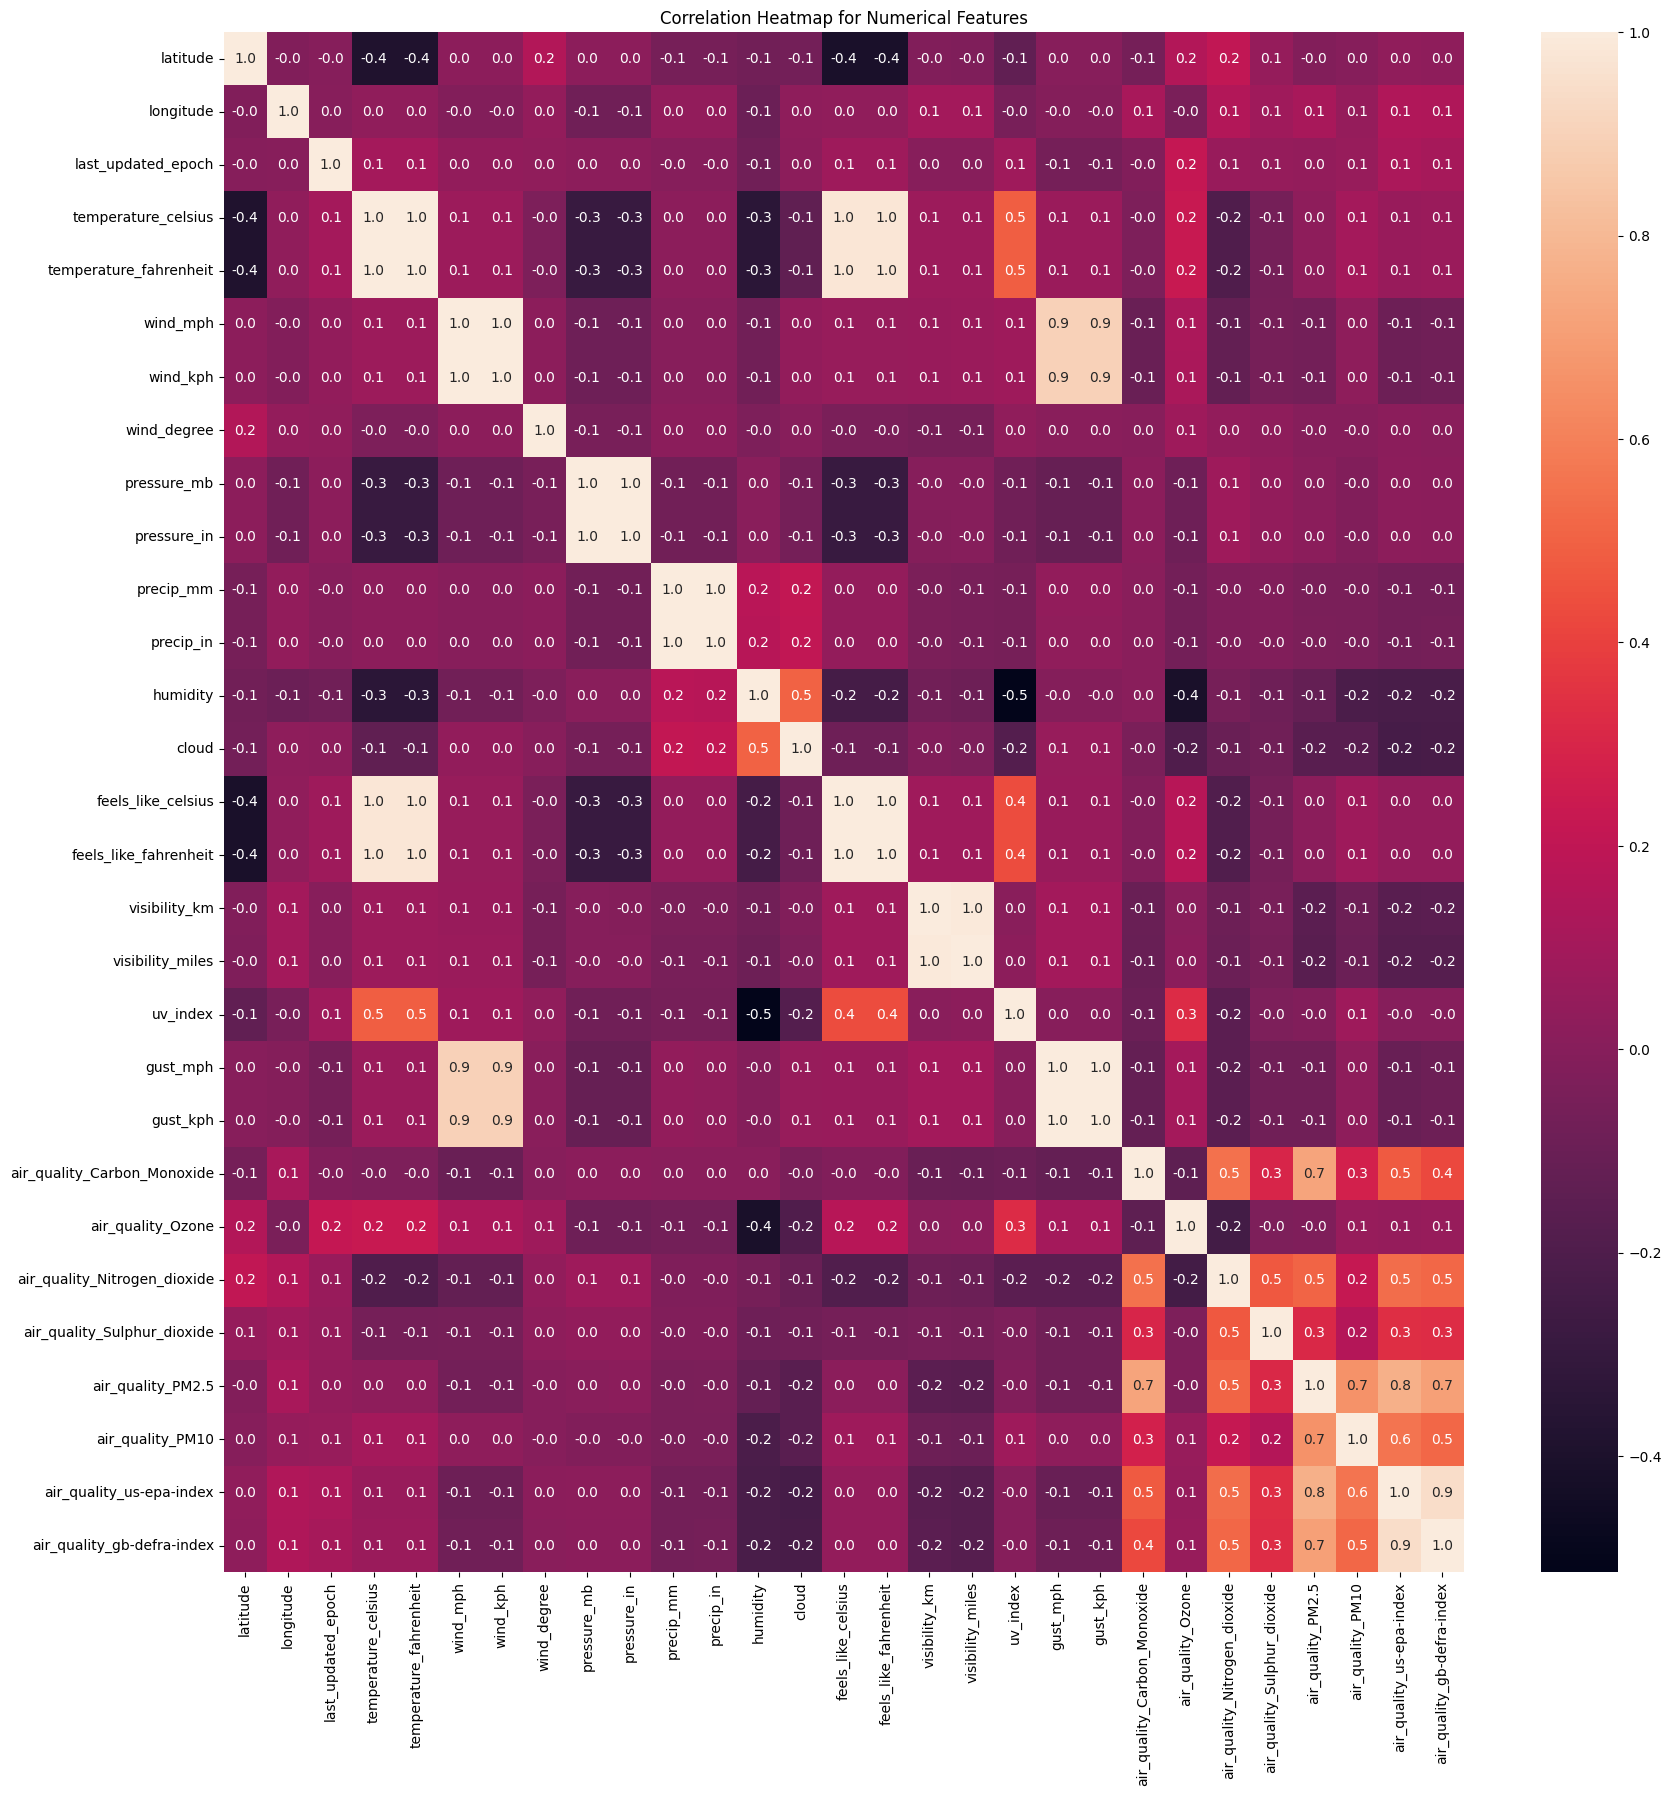

In [83]:
corr = df_num.corr()

plt.figure(figsize=(20,20))
sns.heatmap(corr, fmt=".1f", annot=True)
plt.title("Correlation Heatmap for Numerical Features")
plt.show()

In [84]:
df.shape

(135023, 35)

Adding new column "Region" 

In [85]:
import pycountry_convert as pc
def country_to_continent(country_name):
    try:
        country_alpha2 = pc.country_name_to_country_alpha2(country_name)
        continent_code = pc.country_alpha2_to_continent_code(country_alpha2)
        continent_name = {
            "AF": "Africa",
            "AS": "Asia",
            "EU": "Europe",
            "NA": "North America",
            "SA": "South America",
            "OC": "Oceania",
            "AN": "Antarctica"
        }
        return continent_name[continent_code]
    except:
        return "Unknown"

df["region"] = df["country"].apply(country_to_continent)

df['region']



0                  Asia
1                Europe
2                Africa
3                Europe
4                Africa
              ...      
135018    South America
135019             Asia
135020             Asia
135021           Africa
135022           Africa
Name: region, Length: 135023, dtype: object

In [86]:
df_cpy = df.select_dtypes(include='number')
drop_cols = [ "latitude","longitude","last_updated_epoch","cloud"
      "feels_like_celsius", "feels_like_fahrenheit ", "gust_kph","visibility_miles","precip_in","wind_degree","pressure_in","wind_mph","temperature_fahrenheit"
]

df_cpy = df_cpy.drop(columns=[c for c in drop_cols if c in df.columns])
for i in df_cpy.columns:
    df_cpy[i] = df_cpy[i].fillna(df_cpy[i].mean())
for i in df_cpy.columns:
    Q1 = df_cpy[i].quantile(0.25)
    Q3 = df_cpy[i].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df_cpy[i] = df_cpy[i].clip(lower=lower,upper=upper)
df_cpy['last_updated'] = df['last_updated']
df_cpy['region'] = df['region']


Distributions of target columns 

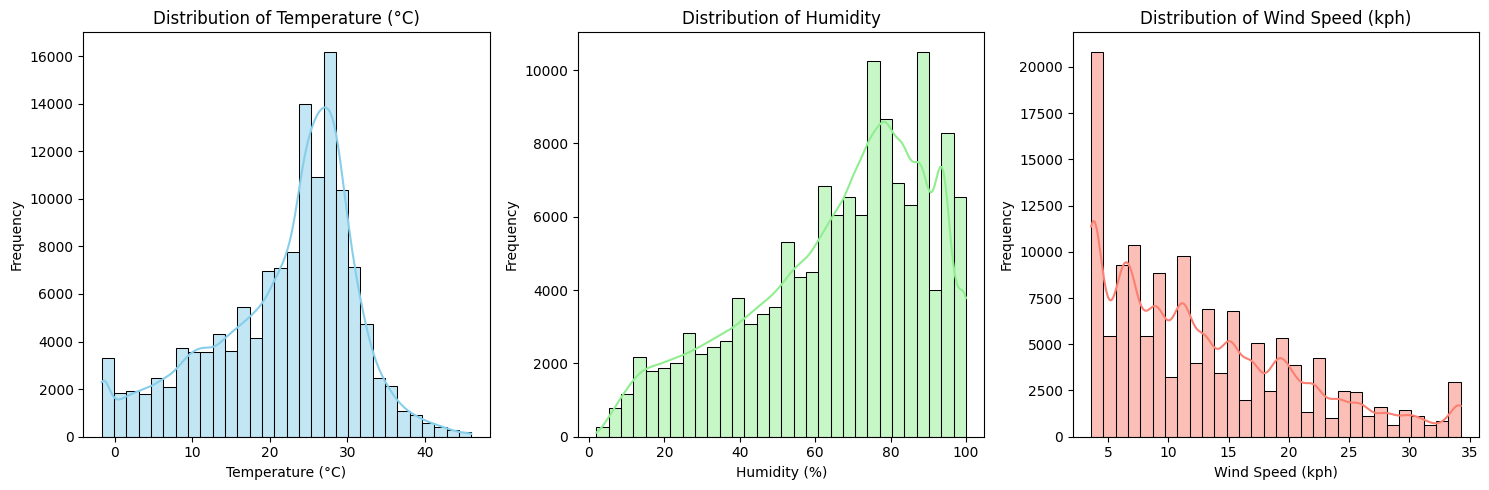

In [88]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Temperature distribution
sns.histplot(df_cpy['temperature_celsius'], bins=30, kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Distribution of Temperature (°C)")
axes[0].set_xlabel("Temperature (°C)")
axes[0].set_ylabel("Frequency")

# Humidity distribution
sns.histplot(df_cpy['humidity'], bins=30, kde=True, ax=axes[1], color="lightgreen")
axes[1].set_title("Distribution of Humidity")
axes[1].set_xlabel("Humidity (%)")
axes[1].set_ylabel("Frequency")

# Wind speed distribution
sns.histplot(df_cpy['wind_kph'], bins=30, kde=True, ax=axes[2], color="salmon")
axes[2].set_title("Distribution of Wind Speed (kph)")
axes[2].set_xlabel("Wind Speed (kph)")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


In [89]:
if 'last_updated' in df_cpy.columns:
    df_cpy['last_updated'] = pd.to_datetime(df_cpy['last_updated'])
    df_cpy.set_index('last_updated', inplace=True)
    monthly_avg = df_cpy.resample('M').mean(numeric_only=True)
    print("Monthly averages:")
    print(monthly_avg.head())

Monthly averages:
              temperature_celsius   wind_kph  pressure_mb  precip_mm  \
last_updated                                                           
2023-08-31              23.093671  11.479905  1011.927215   0.015348   
2023-09-30              22.642941  10.620092  1013.745647   0.010036   
2023-10-31              20.878947  10.839541  1013.485155   0.012368   
2023-11-30              18.701716  11.597914  1012.785132   0.013704   
2023-12-31              17.337571  11.675327  1014.612367   0.013253   

               humidity      cloud  feels_like_celsius  feels_like_fahrenheit  \
last_updated                                                                    
2023-08-31    72.669304  40.495253           25.046677              77.081487   
2023-09-30    72.618300  32.224479           24.106538              75.383843   
2023-10-31    72.121289  34.529015           22.235358              72.017417   
2023-11-30    72.703395  39.667552           19.434591              66.9

C:\Users\prads\AppData\Local\Temp\ipykernel_26184\3754779634.py:2: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_cpy['last_updated'] = pd.to_datetime(df_cpy['last_updated'])
C:\Users\prads\AppData\Local\Temp\ipykernel_26184\3754779634.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg = df_cpy.resample('M').mean(numeric_only=True)


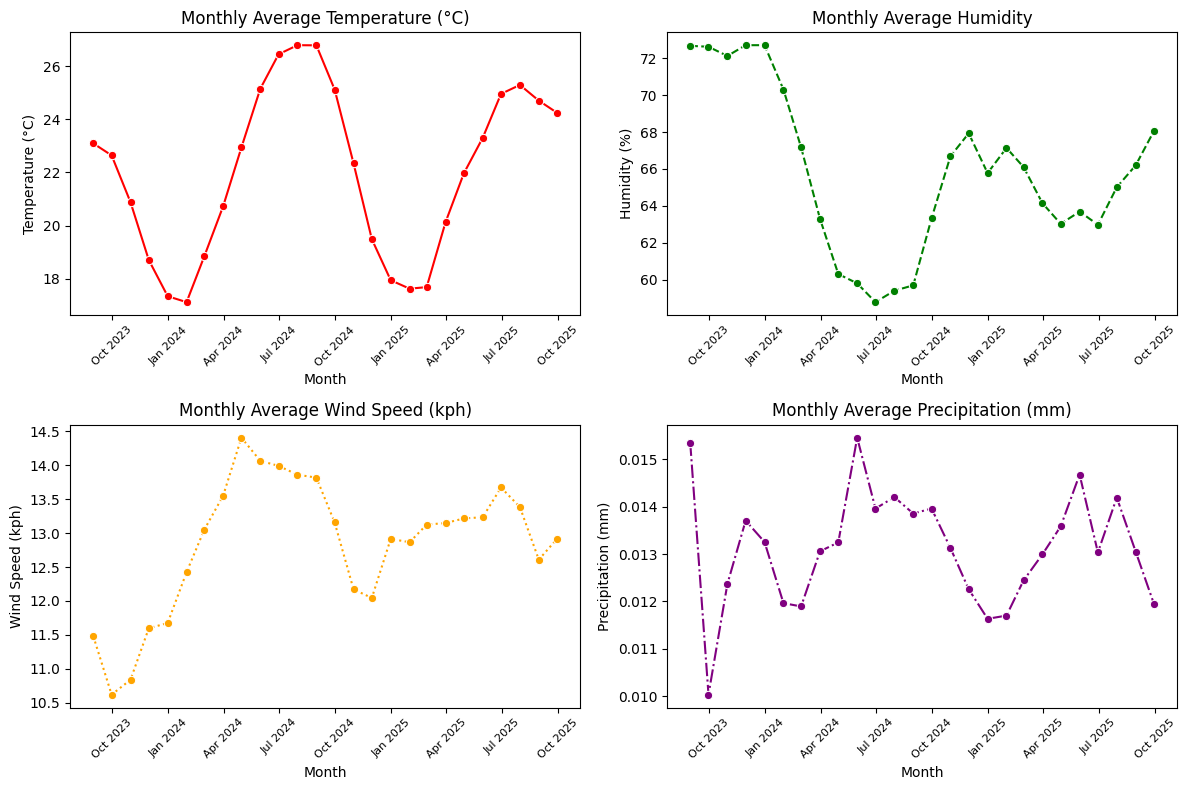

,temperature_celsius,wind_kph,pressure_mb,precip_mm,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,uv_index,gust_mph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,region
last_updated,,,,,,,,,,,,,,,,,,,,
2023-08-29 14:00:00,28.8,11.5,1004.0,0.0,19.0,0.0,26.7,80.1,10.0,7.0,8.3,647.50,130.2,1.2000,0.40,7.9000,11.10000,1.0,1,Asia
2023-08-29 11:30:00,27.0,6.1,1006.0,0.0,54.0,75.0,28.0,82.3,10.0,6.0,7.4,433.90,104.4,3.6000,1.80,28.2000,29.60000,2.0,3,Europe
2023-08-29 10:30:00,28.0,13.0,1014.0,0.0,30.0,25.0,27.4,81.3,10.0,7.0,3.4,647.50,16.6,40.2875,12.60,6.4000,7.90000,1.0,1,Africa
2023-08-29 11:30:00,10.2,9.7,1015.0,0.0,51.0,6.0,8.9,48.0,10.0,4.0,7.4,190.30,68.0,0.2000,0.20,0.5000,0.80000,1.0,1,Europe
2023-08-29 10:30:00,25.0,3.6,1016.0,0.0,69.0,75.0,26.9,80.4,10.0,6.0,3.6,863.05,137.5,40.2875,18.95,63.1125,99.70525,3.5,6,Africa


In [90]:
seasonal_cols = ['temperature_celsius', 'humidity', 'wind_kph', 'precip_mm']
monthly_seasonal = monthly_avg[seasonal_cols]
plt.figure(figsize=(12, 8))
# 1. Temperature
ax1 = plt.subplot(2, 2, 1)
sns.lineplot(x=monthly_seasonal.index, y=monthly_seasonal['temperature_celsius'], marker="o", color="red", ax=ax1,)
ax1.set_title("Monthly Average Temperature (°C)")
ax1.set_xlabel("Month")
ax1.set_ylabel("Temperature (°C)")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax1.tick_params(axis='x', rotation=45, labelsize=8)
# 2. Humidity
ax2 = plt.subplot(2, 2, 2)
sns.lineplot(x=monthly_seasonal.index, y=monthly_seasonal['humidity'], marker="o", color="green",linestyle='--' , ax=ax2)
ax2.set_title("Monthly Average Humidity")
ax2.set_xlabel("Month")
ax2.set_ylabel("Humidity (%)")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax2.tick_params(axis='x', rotation=45, labelsize=8)

# 3. Wind Speed
ax3 = plt.subplot(2, 2, 3)
sns.lineplot(x=monthly_seasonal.index, y=monthly_seasonal['wind_kph'], marker="o", color="orange", linestyle='dotted' ,ax=ax3)
ax3.set_title("Monthly Average Wind Speed (kph)")
ax3.set_xlabel("Month")
ax3.set_ylabel("Wind Speed (kph)")
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax3.tick_params(axis='x', rotation=45, labelsize=8)

# 4. Precipitation
ax4 = plt.subplot(2, 2, 4)
sns.lineplot(x=monthly_seasonal.index, y=monthly_seasonal['precip_mm'], marker="o", color="purple",linestyle='-.' , ax=ax4)
ax4.set_title("Monthly Average Precipitation (mm)")
ax4.set_xlabel("Month")
ax4.set_ylabel("Precipitation (mm)")
ax4.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax4.tick_params(axis='x', rotation=45, labelsize=8)

plt.tight_layout()
plt.show()
df_cpy.head()


In [105]:
import plotly.express as px
country_avg = df.groupby("region")[["temperature_celsius", "humidity", "wind_kph"]].mean().reset_index()
fig = px.bar(
    country_avg,
    x="region",
    y="temperature_celsius",
    color="temperature_celsius",
    hover_data={"humidity": True, "wind_kph": True},
    color_continuous_scale="RdYlBu_r",
    title="Average Temperature (°C) Across Regions"
)
fig.update_layout(xaxis_title="Region", yaxis_title="Avg Temperature (°C)")
fig.show()

In [106]:
# Choropleth: average temperature by country
country_temp = df.groupby('country', as_index=False)['temperature_celsius'].mean()
fig = px.choropleth(
    country_temp,
    locations='country',
    locationmode='country names',
    color='temperature_celsius',
    hover_name='country',
    color_continuous_scale='RdYlBu_r',
    title='Average Temperature by Country (°C)'
)
fig.update_layout(coloraxis_colorbar=dict(title='Avg Temp (°C)'))
fig.show()

C:\Users\prads\AppData\Local\Temp\ipykernel_26184\3608671094.py:3: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



Multilinear Regression

In [100]:
df_lr = df_cpy
df_lr = df_lr.drop('region',axis=1)
X = df_lr.drop('temperature_celsius',axis=1)
Y = df_lr["temperature_celsius"]

# Train/test split, scaling, linear regression
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error: ",mse)
print("Mean Absolute Error: ",mae)
print("Root Mean Squared Error: ",rmse)
print("R2 Score: ",r2)




Mean Squared Error:  2.3847573477631134
Mean Absolute Error:  1.0584175421303583
Root Mean Squared Error:  1.54426595758733
R2 Score:  0.972284514035317


In [99]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_s, y_train)
y_pred_rf = rf.predict(X_test_s)

mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("RF Mean Squared Error:", mse_rf)
print("RF Mean Absolute Error:", mae_rf)
print("RF Root Mean Squared Error:", rmse_rf)
print("RF R2 Score:", r2_rf)




RF Mean Squared Error: 0.5722292033118864
RF Mean Absolute Error: 0.306548185521204
RF Root Mean Squared Error: 0.7564583288667568
RF R2 Score: 0.9933495915348165
